# 01 — Exploratory Data Analysis

Customer Churn Prediction — IBM Telco Customer Churn dataset.

This notebook explores the raw dataset: structure, missing values, target balance, correlations, and feature distributions, to inform the preprocessing and feature engineering steps that follow in `02_Feature_Engineering.ipynb`.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_raw_data
from src.visualization import (
    plot_target_distribution,
    plot_missing_values,
    plot_correlation_heatmap,
    plot_categorical_distributions,
    plot_numerical_distributions,
    plot_boxplots,
    plot_pairplot,
)

%matplotlib inline
pd.set_option('display.max_columns', None)


## 1. Dataset Overview

In [2]:
df = load_raw_data()
print(f'Shape: {df.shape}')
df.head()


2026-07-31 14:21:57 | INFO     | src.data_loader | Loading raw data from C:\Users\ONJ3KOR\Work\Niteesh\customer-churn-prediction-ml\data\raw\Telco-Customer-Churn.csv


2026-07-31 14:21:57 | INFO     | src.data_loader | Loaded dataset with shape (7043, 21)


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Insight:** The dataset has 7,043 customers and 21 columns. `TotalCharges` is loaded as an `object` dtype because it contains blank strings for the 11 customers with zero tenure — this needs numeric coercion during preprocessing. `customerID` is a unique identifier with no predictive value and will be dropped.

## 2. Missing Value Analysis

In [5]:
print(df.isna().sum())
print(f"\nBlank TotalCharges strings: {(df['TotalCharges'].str.strip() == '').sum()}")


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Blank TotalCharges strings: 11


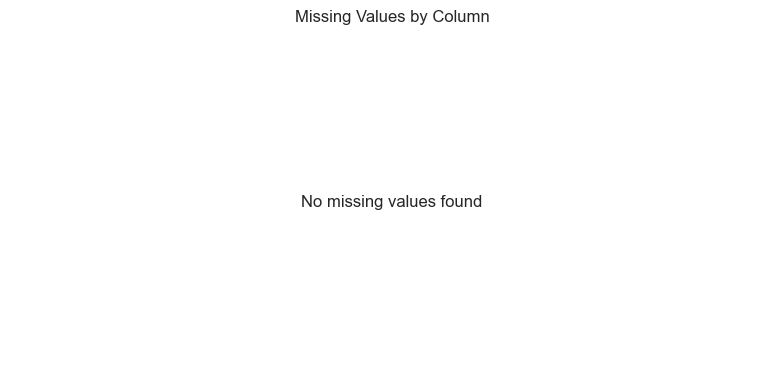

In [6]:
fig = plot_missing_values(df)


**Insight:** `pandas` reports zero missing values because the blanks in `TotalCharges` are empty strings, not `NaN`. Once coerced to numeric they surface as 11 missing values — exactly the customers with `tenure == 0` (brand-new customers who haven't been billed yet). These will be imputed with 0 in preprocessing.

## 3. Target Distribution & Class Imbalance

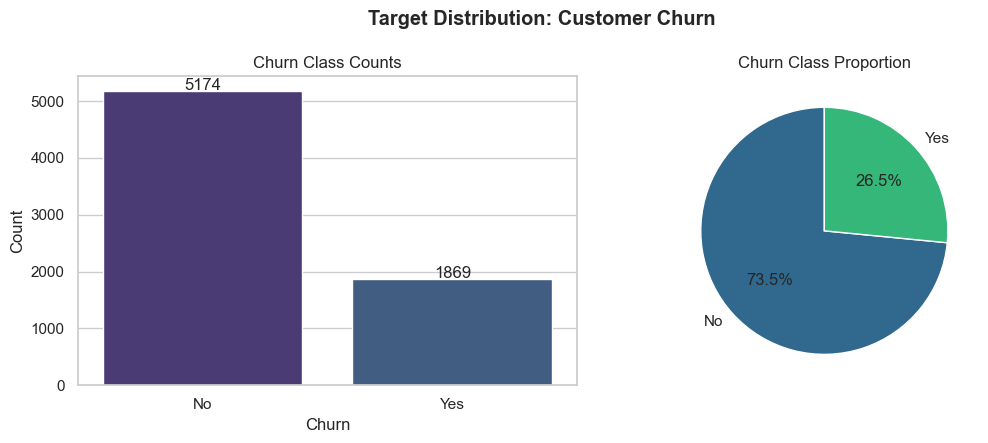

In [7]:
fig = plot_target_distribution(df)


In [8]:
churn_rate = (df['Churn'] == 'Yes').mean()
print(f'Overall churn rate: {churn_rate:.1%}')


Overall churn rate: 26.5%


**Insight:** Only ~26.5% of customers churned — a moderate class imbalance (roughly 3:1). Training on this imbalance directly would bias models toward the majority (non-churn) class, so we apply **SMOTE** oversampling on the training data during modeling.

## 4. Correlation Heatmap

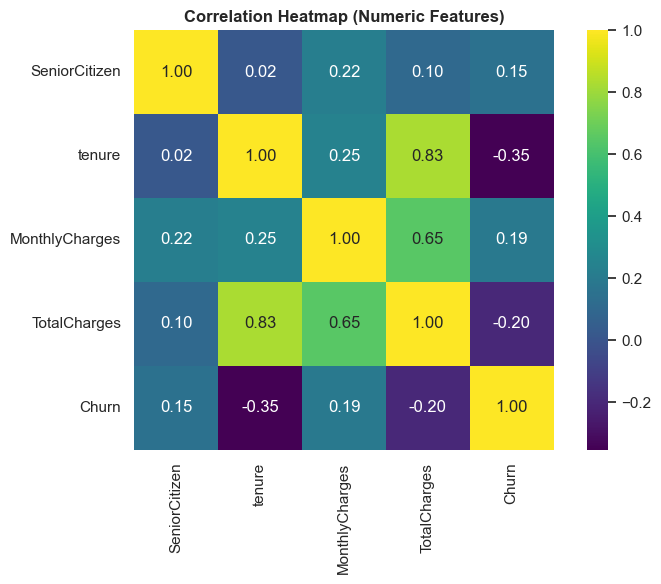

In [9]:
numeric_df = df.copy()
numeric_df['TotalCharges'] = pd.to_numeric(numeric_df['TotalCharges'], errors='coerce')
numeric_df['Churn'] = numeric_df['Churn'].map({'Yes': 1, 'No': 0})
fig = plot_correlation_heatmap(numeric_df)


**Insight:** `tenure` and `TotalCharges` are strongly positively correlated (long-tenured customers accumulate higher total charges), while `tenure` is negatively correlated with churn — newer customers churn more. `MonthlyCharges` correlates positively with churn, hinting that pricier plans are riskier.

## 5. Categorical Feature Distributions

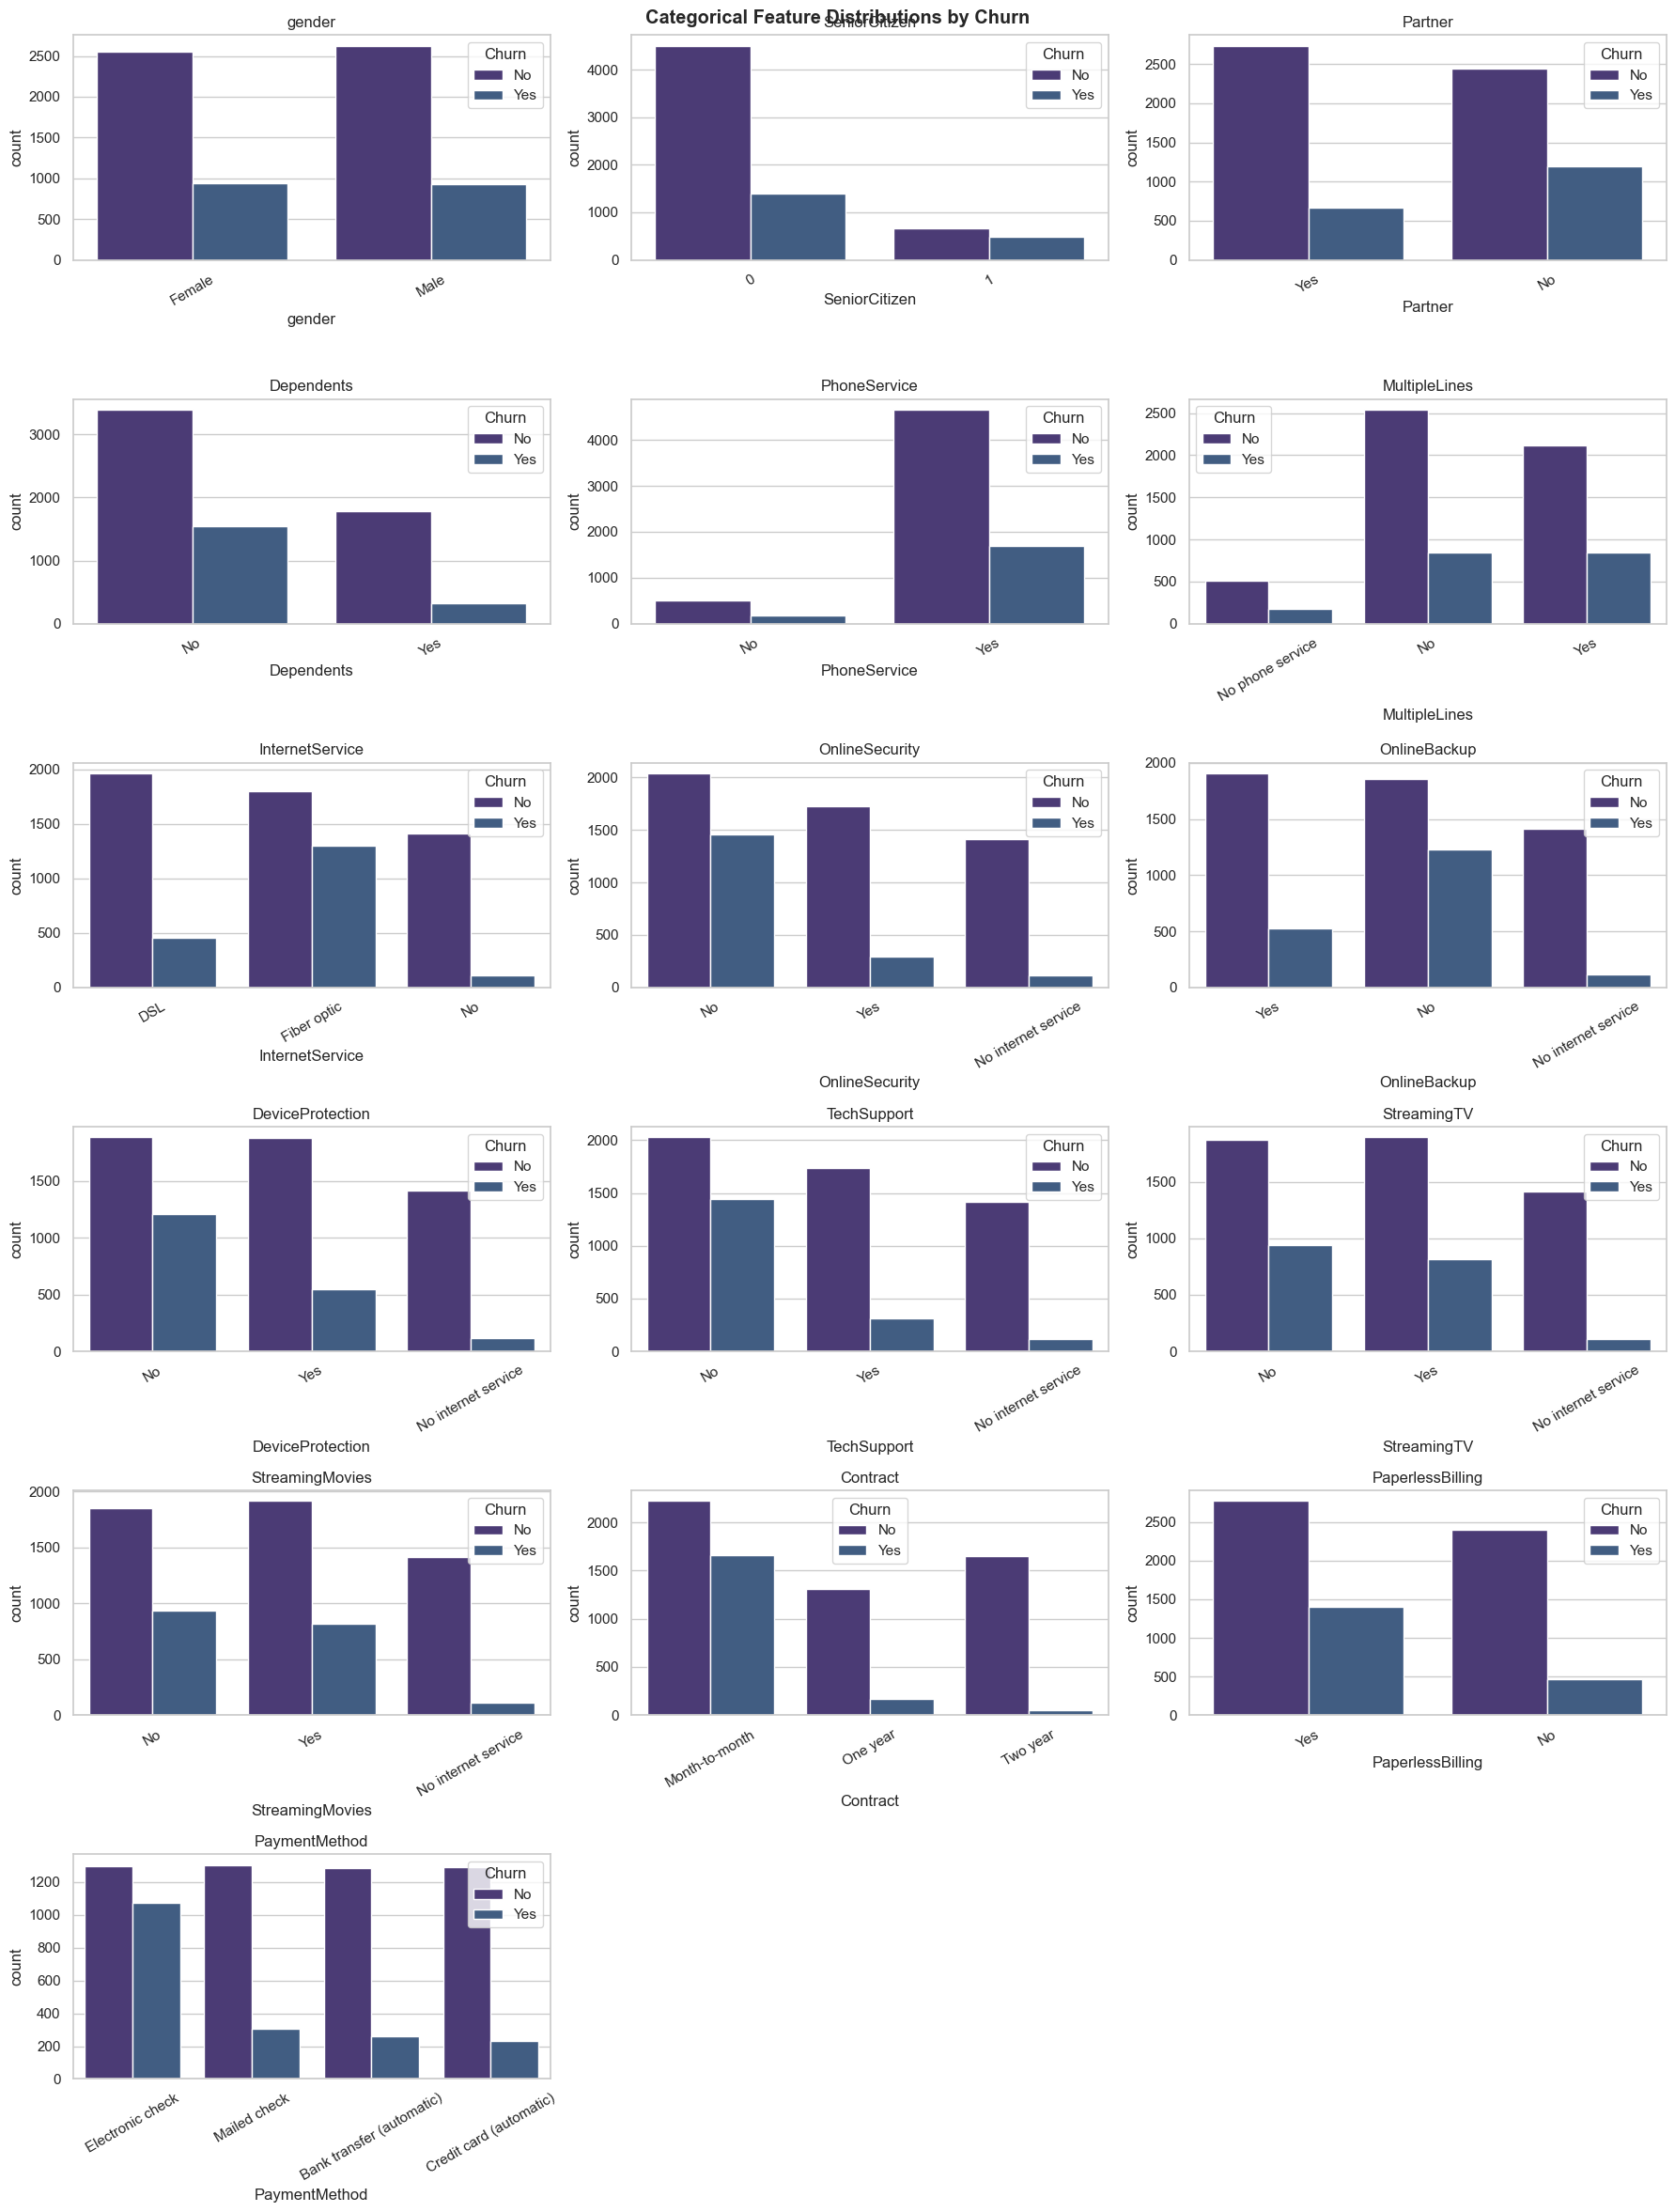

In [10]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod',
]
fig = plot_categorical_distributions(df, categorical_cols)


**Insight:** Month-to-month contracts, fiber-optic internet, electronic-check payment, and the absence of add-on services (online security, tech support) are all visibly associated with higher churn proportions — these will likely be influential features.

## 6. Numerical Feature Distributions

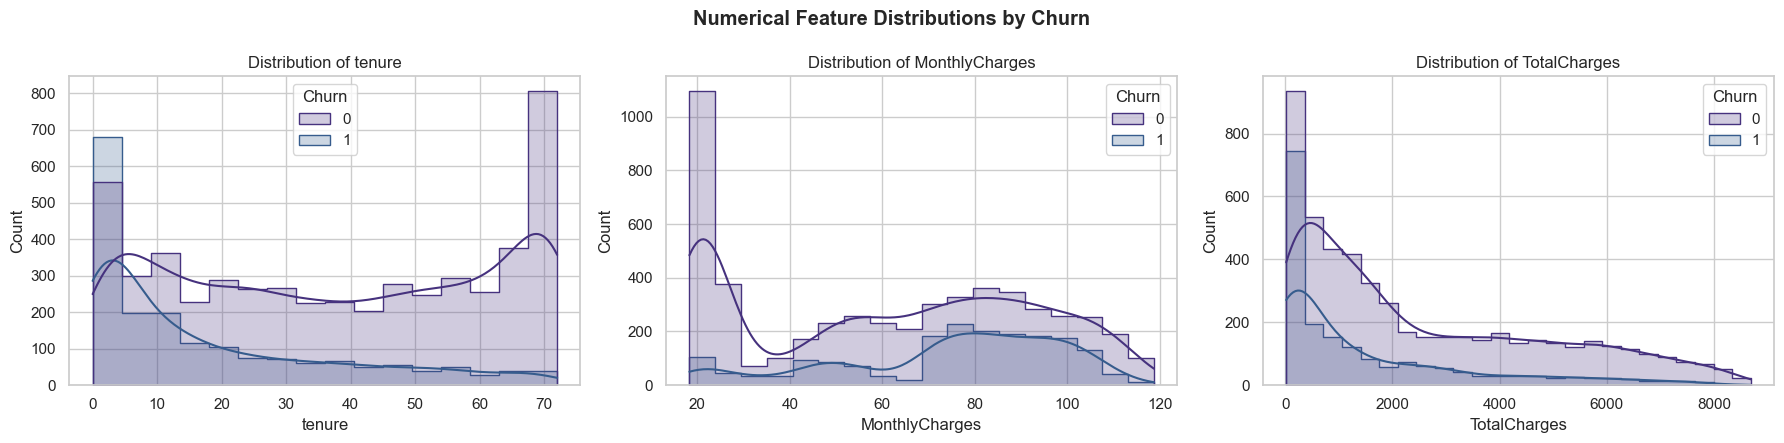

In [11]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig = plot_numerical_distributions(numeric_df, numerical_cols)


**Insight:** Churned customers skew heavily toward low tenure (many churn within the first few months) and moderately higher monthly charges, consistent with the correlation findings above.

## 7. Boxplots — Outlier Inspection

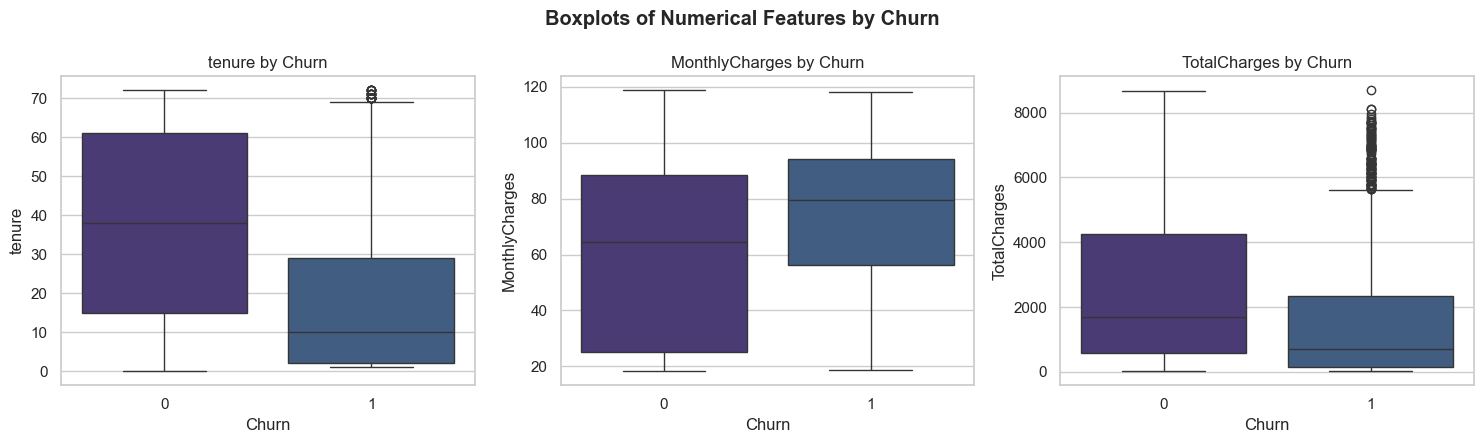

In [12]:
fig = plot_boxplots(numeric_df, numerical_cols)


**Insight:** No extreme outliers are present in `tenure`, `MonthlyCharges`, or `TotalCharges` — the boxplots show the expected spread without unrealistic values, so no outlier removal is necessary.

## 8. Pairplot

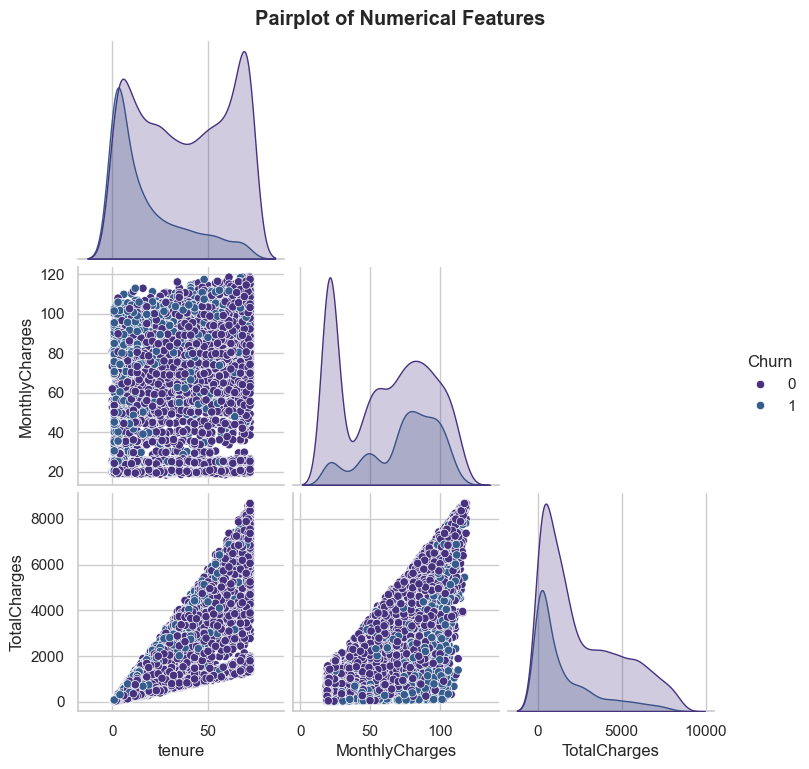

In [13]:
fig = plot_pairplot(numeric_df, numerical_cols)


**Insight:** The pairplot confirms the strong `tenure`–`TotalCharges` relationship and shows churned customers clustering at low tenure across all combinations, with no obvious separable clusters purely from numeric features — categorical service/contract features will carry significant signal too.

## 9. Summary of EDA Findings

- **Class imbalance** (~26.5% churn) → handle with SMOTE.
- **`TotalCharges`** needs numeric coercion + imputation for 11 rows.
- **`customerID`** is a non-predictive identifier → drop.
- Strong churn signal from **tenure**, **contract type**, **internet service type**, **payment method**, and **add-on services**.
- No significant outliers requiring removal.

These findings directly motivate the cleaning and feature engineering steps in the next notebook.